In [2]:
# TASK-SPECIFIC ANALYSIS NOTEBOOK - REVERSAL TASK
# ============================================================================

# Cell 1: Imports and Setup
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import sys

# Custom analysis modules
sys.path.append('/Users/kevinmastro/Library/Mobile Documents/com~apple~CloudDocs/Documents 2/Github/ssm/bandit_models') 
import bandit_plots as bp
import bandit_preprocessing as bpp

sys.path.append('/Users/kevinmastro/Library/Mobile Documents/com~apple~CloudDocs/Documents 2/Github/ssm/bandit_models/bandit_models')
import plot_models_v_mouse as plots
import conditional_probs as cp

# Plotting settings
%matplotlib inline
sns.set(style='ticks', font_scale=1.6, rc={'axes.labelsize':18, 'axes.titlesize':18}) 

# Pandas display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Setup complete!")

Setup complete!


In [3]:
# Cell 2: Load Enhanced Master Data with Metadata
data_path = '/Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/2 - Raw Data/preprocessed_master_merged_data_with_metadata20260226.csv'
df_master = pd.read_csv(data_path)

print(f"Master data loaded: {df_master.shape}")
print(f"Date range: {df_master['Date'].min()} to {df_master['Date'].max()}")
print(f"Animals: {df_master['Animal_Name'].dropna().unique()}")
print(f"Task types: {df_master['Task_Type'].dropna().unique()}")

/var/folders/wd/vm48bm495w3czprrgk3t2dq00000gn/T/ipykernel_71538/4138509065.py:3: DtypeWarning: Columns (34,38,40,69,70,72,74,83,84,89,90,95,98,103,106) have mixed types. Specify dtype option on import or set low_memory=False.
  df_master = pd.read_csv(data_path)


Master data loaded: (338861, 115)
Date range: 2020-12-15 to 2024-03-25
Animals: ['Fiona' 'Zazu' 'Sunflower' 'Tuna' 'Raven' 'Knuckles' 'Salmon' 'Griffin'
 'Griffin_Visual_Discrimination_Task_NoInitiation' 'Coral' 'Sonic']
Task types: ['WhereTask' 'Reversal' 'Reversal_SetChanges' 'Shaping' 'WhatTask']


In [4]:
df_master

,Trial,BlockCount,TrialWithinBlock,Block,Condition,TrialError,ReactionTime,AbsoluteTrialStartTime,Year,Month,Day,Hour,Minute,Second,BehavioralCodes,ObjectStatusRecord,RewardRecord,VariableChanges,CycleRate_1,CycleRate_2,Ver,Target1_name,Target1_x,Target1_y,Target1_xsize,Target1_ysize,Target1_path,Target2_name,Target2_x,Target2_y,Target2_xsize,Target2_ysize,Target2_path,RewardVolume,RewardType,BlockLength,RandomValue,Block_Prob,StimuliChosen,ProbReward,Reward,Animal_Name,Session_Filename,CodeTimes_1,CodeTimes_2,CodeTimes_3,CodeTimes_4,CodeNumbers_1,CodeNumbers_2,CodeNumbers_3,CodeNumbers_4,StartTimes,EndTimes,reward_dur,EyeOffset_1,EyeOffset_2,Eye2Offset_1,Eye2Offset_2,CodeTimes_5,CodeTimes_6,CodeTimes_7,CodeNumbers_5,CodeNumbers_6,CodeNumbers_7,Date,Outcome,Target1_location,Target2_location,Session_ID,PhysicalChoice,PrevPhysicalChoice,PhysicalSwitch,prob_Condition,Task_Type,TaskObject1_Type,TaskObject1_Size_1,TaskObject1_Size_2,TaskObject1_Color_1,TaskObject1_Color_2,TaskObject1_Color_3,TaskObject1_Fill,TaskObject1_LocX,TaskObject1_LocY,TaskObject2_Type,TaskObject2_Source,TaskObject2_LocX,TaskObject2_LocY,TaskObject2_Size1,TaskObject2_Size2,TaskObject3_Type,TaskObject3_Source,TaskObject3_LocX,TaskObject3_LocY,TaskObject3_Size1,TaskObject3_Size2,Session_Type_x,Num_Reversals_x,Num_Cued_Transitions_x,Has_Cued_Transitions_x,Session_Type_y,Num_Reversals_y,Num_Cued_Transitions_y,Has_Cued_Transitions_y,Session_Type_x.1,Num_Reversals_x.1,Num_Cued_Transitions_x.1,Has_Cued_Transitions_x.1,Session_Type_y.1,Num_Reversals_y.1,Num_Cued_Transitions_y.1,Has_Cued_Transitions_y.1,Session_Type,Num_Reversals,Num_Cued_Transitions,Has_Cued_Transitions
0,1,1,1,1,1,6,NaN,0.000000e+00,2021,10,15,12,28,40.427,NaN,NaN,NaN,NaN,49.9975,32.9957,4,pic,7.0,12.0,300.0,300.0,C:\Users\marmo\Documents\MATLAB\MarmosetTask_L...,pic,-7.0,-2.0,300.0,300.0,C:\Users\marmo\Documents\MATLAB\MarmosetTask_L...,0.08,NaN,9999.0,NaN,NaN,TargetB,0.0,Unrewarded,Fiona,20211015_Fiona_100%Con_WhereBlocks1.1_Easy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-10-15,0,TopRight,BottomLeft,2021-10-15_20211015_Fiona_100%Con_WhereBlocks1...,BottomLeft,NaN,NaN,100-0,WhereTask,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Single_Block,0,0,False,NaN,NaN,NaN,NaN,Single_Block,0,0,False,Single_Block,0,0,False
1,2,1,2,1,1,6,NaN,6.885500e+04,2021,10,15,12,29,49.282,NaN,NaN,NaN,NaN,33.3844,11.3957,4,pic,7.0,12.0,300.0,300.0,C:\Users\marmo\Documents\MATLAB\MarmosetTask_L...,pic,-7.0,-2.0,300.0,300.0,C:\Users\marmo\Documents\MATLAB\MarmosetTask_L...,0.08,NaN,9999.0,NaN,NaN,TargetB,0.0,Unrewarded,Fiona,20211015_Fiona_100%Con_WhereBlocks1.1_Easy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-10-15,0,TopRight,BottomLeft,2021-10-15_20211015_Fiona_100%Con_WhereBlocks1...,BottomLeft,BottomLeft,0.0,100-0,WhereTask,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Single_Block,0,0,False,NaN,NaN,NaN,NaN,Single_Block,0,0,False,Single_Block,0,0,False
2,3,1,3,1,1,6,NaN,8.553550e+04,2021,10,15,12,30,5.962,NaN,NaN,NaN,NaN,33.3318,7.7382,4,pic,7.0,12.0,300.0,300.0,C:\Users\marmo\Documents\MATLAB\MarmosetTask_L...,pic,-7.0,-2.0,300.0,300.0,C:\Users\marmo\Documents\MATLAB\MarmosetTask_L...,0.08,NaN,9999.0,NaN,NaN,TargetB,0.0,Unrewarded,Fiona,20211015_Fiona_100%Con_WhereBlocks1.1_Easy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2021-10-15,0,TopRight,BottomLeft,2021-10-15_20211015_Fiona_100%Con_WhereBlocks1...,BottomLeft,BottomLeft,0.0,100-0,WhereTask,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Single_Block,0,0,False,NaN,NaN,NaN,NaN,Single_Block,0,0,False,Single_Block,0,0,False
3,4,1,4,1,1,0,NaN,9.276853e+04,2021,10,15,12,30,13.195,NaN,NaN,NaN,NaN,33.3414,5.9564,4,pic,7.0,12.0,300.0,300.0,C:\Users\marmo\Documents\MATLAB\MarmosetTask_L..

In [5]:
# Cell 3: Create a consistent physical choice and physical switch column
# ============================================================================
# ============================================================================
#  We must do this becuase the TargetA is ALWAYS the high probability port
#  and the TargetB is ALWAYS the low probability port. Thus, Target is  always 1 and Decision is always 1 = highPort, 0 = lowPort. 
# ============================================================================
# Solution. We must code the two choices based on the block. So for reversal task, every odd block is one choice and then that option needs to be reversed for the next block.
# ============================================================================

print("Creating consistent physical choice column...")

df_with_choice = df_master.copy()

# Map StimuliChosen to a consistent 0/1 based on block parity
# In even blocks: TargetA=0, TargetB=1
# In odd blocks: TargetA=1, TargetB=0

# def map_to_physical_choice(row):
#     if pd.isna(row['StimuliChosen']) or pd.isna(row['Block']):
#         return np.nan
    
#     if row['Block'] % 2 == 0:  # Even block
#         return 0 if row['StimuliChosen'] == 'TargetA' else 1
#     else:  # Odd block
#         return 1 if row['StimuliChosen'] == 'TargetA' else 0

# df_with_choice['PhysicalChoice'] = df_with_choice.apply(map_to_physical_choice, axis=1)

# # Cell 12A: Switching Probability with Physical Choices
# # ============================================================================

# print("Calculating switching probability by block position (PHYSICAL LOCATIONS)...")
# df_with_choice['PhysicalSwitch'] = df_with_choice['PhysicalChoice'].diff().fillna(0).astype(int)
# df_with_choice['PhysicalSwitch'] = df_with_choice['PhysicalSwitch'].abs()


# print("Sample of new PhysicalChoice column:")
# example_session = df_with_choice['Session_ID'].iloc[0]
# example = df_with_choice[df_with_choice['Session_ID'] == example_session].sort_values('Trial').head(30)
# print(example[['Trial', 'Block', 'StimuliChosen', 'PhysicalChoice', 'PhysicalSwitch', 'Decision', 'Reward']])

# # Verify it makes sense at a block transition
# print("\nAround a block transition:")
# trans_example = df_with_choice[df_with_choice['Session_ID'] == example_session].sort_values('Trial')
# trans_point = trans_example[trans_example['Block'] == trans_example['Block'].shift(1) + 1].index[0]
# trans_idx = trans_example.index.get_loc(trans_point)
# print(trans_example.iloc[trans_idx-3:trans_idx+5][['Trial', 'Block', 'StimuliChosen', 'PhysicalChoice', 'PhysicalSwitch', 'Decision', 'Reward']])

Creating consistent physical choice column...


In [10]:
# Cell 3: FILTER PARAMETERS - EDIT THIS CELL TO SELECT YOUR DATA
# ============================================================================

# Task selection
TASK_TYPE = 'Reversal'  # Options: 'Reversal', 'WhereTask', 'What Task'

# Probability condition (set to None to include all)
PROB_CONDITION = '80-20' #'100-0'  # Options: '100-0', '80-20', '90-10', None

# Animals to include (set to None or 'all' to include all)
ANIMALS = None  # Options: None, 'all', or ['Sonic', 'Knuckles', ...]

# Minimum trials per animal (animals with fewer trials will be excluded)
MIN_TRIALS_PER_ANIMAL = 500

# Date range (set to None to include all dates)
DATE_START = None  # Format: 'YYYY-MM-DD' or None
DATE_END = None    # Format: 'YYYY-MM-DD' or None

# ===== REVERSAL-SPECIFIC FILTERS =====
# Session type filter (only applies when TASK_TYPE = 'Reversal')
REVERSAL_SESSION_TYPE = '2-ABT'  # Options: '2-ABT', 'mixed', None (for all)

# ============================================================================
print("✓ Filter parameters set!")
print(f"  Task: {TASK_TYPE}")
print(f"  Probability: {PROB_CONDITION if PROB_CONDITION else 'All'}")
print(f"  Animals: {ANIMALS if ANIMALS and ANIMALS != 'all' else 'All'}")
print(f"  Minimum trials per animal: {MIN_TRIALS_PER_ANIMAL}")
if TASK_TYPE == 'Reversal' and REVERSAL_SESSION_TYPE:
    print(f"  Reversal session type: {REVERSAL_SESSION_TYPE}")

✓ Filter parameters set!
  Task: Reversal
  Probability: 80-20
  Animals: All
  Minimum trials per animal: 500
  Reversal session type: 2-ABT


In [11]:
# Cell 4: Apply Filters to the df_with_choice dataframe
df = df_with_choice.copy()

print("Applying filters...\n")
MIN_TRIALS_PER_ANIMAL = 100  # or whatever minimum you want

# Filter by task type
df = df[df['Task_Type'] == TASK_TYPE]
print(f"✓ Task filter ({TASK_TYPE}): {len(df):,} trials, {df['Session_ID'].nunique()} sessions")

# Filter by probability condition
if PROB_CONDITION:
    df = df[df['prob_Condition'] == PROB_CONDITION]
    print(f"✓ Probability filter ({PROB_CONDITION}): {len(df):,} trials, {df['Session_ID'].nunique()} sessions")

# Filter by animals
if ANIMALS and ANIMALS != 'all':
    df = df[df['Animal_Name'].isin(ANIMALS)]
    print(f"✓ Animal filter: {len(df):,} trials, {df['Session_ID'].nunique()} sessions")

print(f"DEBUG: MIN_TRIALS_PER_ANIMAL = {MIN_TRIALS_PER_ANIMAL} (type: {type(MIN_TRIALS_PER_ANIMAL)})")


# Filter by minimum trials per animal
if MIN_TRIALS_PER_ANIMAL:
    print(f"✓ Minimum trials filter ({MIN_TRIALS_PER_ANIMAL}):")
    animal_trial_counts = df['Animal_Name'].value_counts()
    animals_to_keep = animal_trial_counts[animal_trial_counts >= MIN_TRIALS_PER_ANIMAL].index
    animals_excluded = animal_trial_counts[animal_trial_counts < MIN_TRIALS_PER_ANIMAL]
    
    if len(animals_excluded) > 0:
        print(f"✓ Minimum trials filter ({MIN_TRIALS_PER_ANIMAL}): Excluding {len(animals_excluded)} animals:")
        for animal, count in animals_excluded.items():
            print(f"    - {animal}: {count} trials")
    
    df = df[df['Animal_Name'].isin(animals_to_keep)]
    print(f"  → {len(df):,} trials, {df['Session_ID'].nunique()} sessions remaining")

# Filter by date range
if DATE_START:
    df = df[df['Date'] >= DATE_START]
    print(f"✓ Start date filter ({DATE_START}): {len(df):,} trials, {df['Session_ID'].nunique()} sessions")
if DATE_END:
    df = df[df['Date'] <= DATE_END]
    print(f"✓ End date filter ({DATE_END}): {len(df):,} trials, {df['Session_ID'].nunique()} sessions")

# ===== REVERSAL-SPECIFIC FILTERS =====
if TASK_TYPE == 'Reversal' and REVERSAL_SESSION_TYPE:
    df = df[df['Session_Type'] == REVERSAL_SESSION_TYPE]
    print(f"✓ Reversal session type filter ({REVERSAL_SESSION_TYPE}): {len(df):,} trials, {df['Session_ID'].nunique()} sessions")

# Filter by minimum trials per animal
if MIN_TRIALS_PER_ANIMAL:
    print(f"✓ Minimum trials filter ({MIN_TRIALS_PER_ANIMAL}):")
    animal_trial_counts = df['Animal_Name'].value_counts()
    animals_to_keep = animal_trial_counts[animal_trial_counts >= MIN_TRIALS_PER_ANIMAL].index
    animals_excluded = animal_trial_counts[animal_trial_counts < MIN_TRIALS_PER_ANIMAL]
    
    if len(animals_excluded) > 0:
        print(f"✓ Minimum trials filter ({MIN_TRIALS_PER_ANIMAL}): Excluding {len(animals_excluded)} animals:")
        for animal, count in animals_excluded.items():
            print(f"    - {animal}: {count} trials")
    
    df = df[df['Animal_Name'].isin(animals_to_keep)]
    print(f"  → {len(df):,} trials, {df['Session_ID'].nunique()} sessions remaining")

print(f"\n{'='*70}")
print(f"FINAL DATASET")
print(f"{'='*70}")
print(f"Trials: {len(df):,}")
print(f"Sessions: {df['Session_ID'].nunique()}")
print(f"Animals: {list(df['Animal_Name'].dropna().unique())}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")

if TASK_TYPE == 'Reversal':
    print(f"\nSession types:")
    print(df.groupby('Session_ID')['Session_Type'].first().value_counts())
    print(f"\nReversals per session (mean): {df.groupby('Session_ID')['Num_Reversals'].first().mean():.1f}")
    print(f"Cued transitions per session (mean): {df.groupby('Session_ID')['Num_Cued_Transitions'].first().mean():.1f}")

print(f"\nTrials per animal:")
print(df['Animal_Name'].value_counts())
print(f"{'='*70}")

Applying filters...

✓ Task filter (Reversal): 104,871 trials, 386 sessions
✓ Probability filter (80-20): 62,827 trials, 187 sessions
DEBUG: MIN_TRIALS_PER_ANIMAL = 100 (type: <class 'int'>)
✓ Minimum trials filter (100):
  → 62,827 trials, 187 sessions remaining
✓ Reversal session type filter (2-ABT): 36,673 trials, 100 sessions
✓ Minimum trials filter (100):
  → 36,673 trials, 100 sessions remaining

FINAL DATASET
Trials: 36,673
Sessions: 100
Animals: ['Fiona', 'Zazu', 'Sunflower', 'Knuckles', 'Sonic']
Date range: 2022-04-25 to 2024-03-25

Session types:
Session_Type
2-ABT    100
Name: count, dtype: int64

Reversals per session (mean): 1.0
Cued transitions per session (mean): 0.0

Trials per animal:
Animal_Name
Knuckles     11050
Sunflower     9924
Sonic         7171
Fiona         5224
Zazu          3304
Name: count, dtype: int64


In [12]:
# Cell 5: Quick Data Check
print("=== Data Quality Check ===\n")
print(f"Missing Animal_Name: {df['Animal_Name'].isna().sum()} trials")
print(f"Missing Reward: {df['Reward'].isna().sum()} trials")
print(f"Missing Block: {df['Block'].isna().sum()} trials")
print(f"\nReward distribution:")
print(df['Reward'].value_counts())

=== Data Quality Check ===

Missing Animal_Name: 0 trials
Missing Reward: 0 trials
Missing Block: 0 trials

Reward distribution:
Reward
Rewarded      22016
Unrewarded    14657
Name: count, dtype: int64


In [13]:
df

,Trial,BlockCount,TrialWithinBlock,Block,Condition,TrialError,ReactionTime,AbsoluteTrialStartTime,Year,Month,Day,Hour,Minute,Second,BehavioralCodes,ObjectStatusRecord,RewardRecord,VariableChanges,CycleRate_1,CycleRate_2,Ver,Target1_name,Target1_x,Target1_y,Target1_xsize,Target1_ysize,Target1_path,Target2_name,Target2_x,Target2_y,Target2_xsize,Target2_ysize,Target2_path,RewardVolume,RewardType,BlockLength,RandomValue,Block_Prob,StimuliChosen,ProbReward,Reward,Animal_Name,Session_Filename,CodeTimes_1,CodeTimes_2,CodeTimes_3,CodeTimes_4,CodeNumbers_1,CodeNumbers_2,CodeNumbers_3,CodeNumbers_4,StartTimes,EndTimes,reward_dur,EyeOffset_1,EyeOffset_2,Eye2Offset_1,Eye2Offset_2,CodeTimes_5,CodeTimes_6,CodeTimes_7,CodeNumbers_5,CodeNumbers_6,CodeNumbers_7,Date,Outcome,Target1_location,Target2_location,Session_ID,PhysicalChoice,PrevPhysicalChoice,PhysicalSwitch,prob_Condition,Task_Type,TaskObject1_Type,TaskObject1_Size_1,TaskObject1_Size_2,TaskObject1_Color_1,TaskObject1_Color_2,TaskObject1_Color_3,TaskObject1_Fill,TaskObject1_LocX,TaskObject1_LocY,TaskObject2_Type,TaskObject2_Source,TaskObject2_LocX,TaskObject2_LocY,TaskObject2_Size1,TaskObject2_Size2,TaskObject3_Type,TaskObject3_Source,TaskObject3_LocX,TaskObject3_LocY,TaskObject3_Size1,TaskObject3_Size2,Session_Type_x,Num_Reversals_x,Num_Cued_Transitions_x,Has_Cued_Transitions_x,Session_Type_y,Num_Reversals_y,Num_Cued_Transitions_y,Has_Cued_Transitions_y,Session_Type_x.1,Num_Reversals_x.1,Num_Cued_Transitions_x.1,Has_Cued_Transitions_x.1,Session_Type_y.1,Num_Reversals_y.1,Num_Cued_Transitions_y.1,Has_Cued_Transitions_y.1,Session_Type,Num_Reversals,Num_Cued_Transitions,Has_Cued_Transitions
30693,1,1,1,5,5,6,NaN,0.000000e+00,2022,4,25,8,38,8.635,NaN,NaN,NaN,NaN,33.3356,40.1050,4,pic,6.0,-8.0,300.0,300.0,C:\Users\marmosets\Documents\MATLAB\MarmosetTa...,pic,-6.0,-8.0,300.0,300.0,C:\Users\marmosets\Documents\MATLAB\MarmosetTa...,0.07,50:50 Sweetened:Unsweetened Vanilla Almond Milk,20.0,5.0,3.0,TargetB,0.2,Unrewarded,Fiona,20220425_Fiona_Reversal3.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-04-25,0,BottomRight,BottomLeft,2022-04-25_20220425_Fiona_Reversal3.1,BottomLeft,NaN,NaN,80-20,Reversal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2-ABT,1.0,0.0,False,2-ABT,1,0,False,2-ABT,1.0,0.0,False,2-ABT,1,0,False,2-ABT,1,0,False
30694,2,1,2,5,5,0,NaN,1.360519e+05,2022,4,25,8,40,24.687,NaN,NaN,NaN,NaN,16.7016,8.9380,4,pic,6.0,-8.0,300.0,300.0,C:\Users\marmosets\Documents\MATLAB\MarmosetTa...,pic,-6.0,-8.0,300.0,300.0,C:\Users\marmosets\Documents\MATLAB\MarmosetTa...,0.07,50:50 Sweetened:Unsweetened Vanilla Almond Milk,20.0,8.0,3.0,TargetA,0.8,Rewarded,Fiona,20220425_Fiona_Reversal3.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-04-25,1,BottomRight,BottomLeft,2022-04-25_20220425_Fiona_Reversal3.1,BottomRight,BottomLeft,1.0,80-20,Reversal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2-ABT,1.0,0.0,False,2-ABT,1,0,False,2-ABT,1.0,0.0,False,2-ABT,1,0,False,2-ABT,1,0,False
30695,3,1,3,5,5,0,NaN,1.431673e+05,2022,4,25,8,40,31.802,NaN,NaN,NaN,NaN,16.7499,9.9273,4,pic,6.0,-8.0,300.0,300.0,C:\Users\marmosets\Documents\MATLAB\MarmosetTa...,pic,-6.0,-8.0,300.0,300.0,C:\Users\marmosets\Documents\MATLAB\MarmosetTa...,0.07,50:50 Sweetened:Unsweetened Vanilla Almond Milk,20.0,7.0,3.0,TargetA,0.8,Rewarded,Fiona,20220425_Fiona_Reversal3.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-04-25,1,BottomRight,BottomLeft,2022-04-25_20220425_Fiona_Reversal3.1,BottomRight,BottomRight,0.0,80-20,Reversal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2-ABT,1.0,0.0,False,2-ABT,1,0,False,2-ABT,1.0,0.0,False,2-ABT,1,0,False,2-ABT,1,0,False
30696,4,1,4,5,5,6,NaN,1.549159e+05,2022,4,25,8,40,43.551,NaN,NaN,NaN,NaN,16.7042,5.7756,4,pic,6.0,-8.0,300.0,300.0,C:\Users\marmosets\Documents\MATL

In [14]:
# save the filted df and name after the filters
dataframe_path = '/Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/4 - Outputs/1-dataframes'
dataframe_name = f'filtered_df_{TASK_TYPE}_{PROB_CONDITION}_{REVERSAL_SESSION_TYPE}_{MIN_TRIALS_PER_ANIMAL}.csv'
df.to_csv(os.path.join(dataframe_path, dataframe_name), index=False)

## Reversal Task Analysis (2-ABT)

In [111]:
# define the save_path and the useful naming vairables to be used for all the plots from the filters above
save_path = '/Users/kevinmastro/Library/CloudStorage/GoogleDrive-kmastro@broadinstitute.org/Shared drives/Broad Marmoset/2-Experiments/5 - Monkey Logic Task/4 - Outputs/2-graphs'
os.makedirs(save_path, exist_ok=True)

# define the useful naming vairables to be used for all the plots from the filters above
task_type = df['Task_Type'].iloc[0]
prob_condition = df['prob_Condition'].iloc[0]
animals = df['Animal_Name'].dropna().unique()

# make sure text is saved as text in svg files
plt.rcParams['svg.fonttype'] = 'none'

# define fontsize for all text in the plots, linewidth for all lines, and markersize for all points
fontsize = 8
linewidth = 0.5
markersize = 2

# define the colors for the animals
colors = sns.color_palette('Set1', len(animals))




In [112]:
# Cell 6A FIXED AGAIN: Capture ALL Reversals (Both Directions)
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

print("Preparing reversal-aligned learning curve (ALL REVERSALS - BOTH DIRECTIONS)...")

# Prepare data structure for reversal-aligned analysis
reversal_data = []

# Process each session
for session_id in df['Session_ID'].unique():
    session_df = df[df['Session_ID'] == session_id].sort_values('Trial').copy()
    session_type = session_df['Session_Type'].iloc[0]
    
    # Find ALL block transitions
    session_df['block_changed'] = session_df['Block'] != session_df['Block'].shift(1)
    block_changes = session_df[session_df['block_changed'] & (session_df.index != session_df.index[0])]
    
    # For 2-ABT, ALL transitions are reversals (1↔2)
    # For mixed sessions, only odd→even are reversals
    for idx in block_changes.index:
        prev_idx = session_df.index[session_df.index.get_loc(idx) - 1]
        prev_block = session_df.loc[prev_idx, 'Block']
        curr_block = session_df.loc[idx, 'Block']
        
        is_reversal = False
        
        if session_type == '2-ABT':
            # In 2-ABT, all transitions are reversals
            is_reversal = True
        elif session_type == 'mixed':
            # In mixed, only odd→even transitions are reversals
            is_reversal = (prev_block % 2 == 1 and curr_block == prev_block + 1)
        
        if is_reversal:
            reversal_trial = session_df.loc[idx, 'Trial']
            
            # Get trials around reversal
            window_before = 10
            window_after = 20
            
            for rel_trial in range(-window_before, window_after + 1):
                abs_trial = reversal_trial + rel_trial
                trial_data = session_df[session_df['Trial'] == abs_trial]
                
                if len(trial_data) == 0:
                    continue
                    
                trial_data = trial_data.iloc[0]
                
                # Determine if chose correctly
                chose_correctly = trial_data['Decision'] == trial_data['Target']
                was_rewarded = trial_data['Reward'] == 'Rewarded'
                switch = trial_data['PhysicalSwitch']
                
                reversal_data.append({
                    'session_id': session_id,
                    'animal': trial_data['Animal_Name'],
                    'trial_relative': rel_trial,
                    'chose_correct': chose_correctly,
                    'rewarded': was_rewarded,
                    'block': trial_data['Block'],
                    'switch': switch,
                    'transition': f"{int(prev_block)}→{int(curr_block)}"
                })

# Convert to dataframe
reversal_df = pd.DataFrame(reversal_data)

print(f"Total reversals captured: {reversal_df.groupby('session_id')['trial_relative'].apply(lambda x: (x==0).sum()).sum()}")
print(f"Sessions with reversals: {reversal_df['session_id'].nunique()}")
print(f"Total reversal-aligned trials: {len(reversal_df)}")
print(f"\nAnimals included:")
print(reversal_df['animal'].value_counts())
print(f"\nTransition types:")
print(reversal_df[reversal_df['trial_relative']==0]['transition'].value_counts())

Preparing reversal-aligned learning curve (ALL REVERSALS - BOTH DIRECTIONS)...
Total reversals captured: 187
Sessions with reversals: 19
Total reversal-aligned trials: 5640

Animals included:
Raven    2588
Zazu     1772
Fiona    1280
Name: animal, dtype: int64

Transition types:
1→2    95
2→1    92
Name: transition, dtype: int64


Plotting learning curve with individual animals...


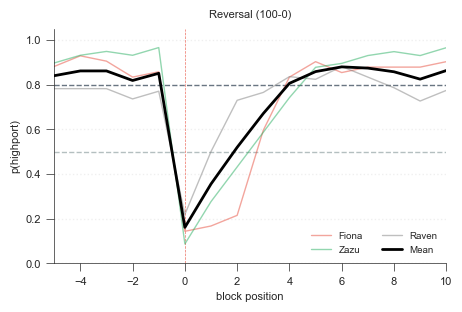


PER-ANIMAL STATISTICS
Fiona       : Pre=0.886, Early=0.390, Late=0.762
Raven       : Pre=0.763, Early=0.607, Late=0.688
Zazu        : Pre=0.912, Early=0.424, Late=0.792


In [113]:
# Cell 6B: Learning Curve with Individual Animal Lines
# ============================================================================

print("Plotting learning curve with individual animals...")

# Calculate overall learning curve (same as before)
learning_curve = reversal_df.groupby('trial_relative').agg({
    'chose_correct': ['mean', 'sem', 'count']
}).reset_index()
learning_curve.columns = ['trial_relative', 'mean_correct', 'sem', 'n_trials']
learning_curve['ci_95'] = 1.96 * learning_curve['sem']

# Calculate learning curve for each animal
animal_curves = {}
for animal in reversal_df['animal'].unique():
    animal_data = reversal_df[reversal_df['animal'] == animal]
    animal_curve = animal_data.groupby('trial_relative')['chose_correct'].mean().reset_index()
    animal_curve.columns = ['trial_relative', 'mean_correct']
    animal_curves[animal] = animal_curve

# Create the figure
fig, ax = plt.subplots(figsize=(5, 3.5))
fig.patch.set_facecolor('white')

# Define colors for animals
animal_colors = {
    'Fiona': '#e74c3c',
    'Knuckles': '#3498db', 
    'Sonic': '#9b59b6',
    'Sunflower': '#f39c12',
    'Zazu': '#27ae60'
}

# Plot individual animal lines FIRST (behind)
for animal, curve_data in animal_curves.items():
    color = animal_colors.get(animal, 'gray')
    ax.plot(curve_data['trial_relative'], curve_data['mean_correct'], 
            color=color, linewidth=1, alpha=0.5, label=animal, zorder=2)

# Plot overall mean on TOP
x = learning_curve['trial_relative']
y = learning_curve['mean_correct']
error = learning_curve['ci_95']

# Shaded error region
# ax.fill_between(x, y - error, y + error, color='black', alpha=0.15, zorder=3)

# Mean line
ax.plot(x, y, color='black', linewidth=2, label='Mean', zorder=4)

# Reference lines
ax.axhline(0.5, color='#95a5a6', linestyle='--', linewidth=1, alpha=0.7, zorder=1)
ax.axhline(optimal_rate, color='#2c3e50', linestyle='--', linewidth=1, alpha=0.7, zorder=1)

# Reversal point
ax.axvline(0, color='#e74c3c', linestyle='--', linewidth=0.5, alpha=0.8, zorder=1)

# Styling
ax.set_xlabel('block position', fontsize=8)
ax.set_ylabel('p(highport)', fontsize=8)
ax.set_title(f'{TASK_TYPE} ({PROB_CONDITION})', 
             fontsize=8, pad=8)
ax.set_ylim([0.0, 1.05])
ax.set_xlim(-5, 10)
ax.legend(fontsize=7, frameon=False, loc='best', ncol=2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize=8, width=0.5)
ax.grid(axis='y', alpha=0.3, linestyle=':', zorder=0)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)

plt.tight_layout()
plt.savefig(os.path.join(save_path, f'{task_type}_{prob_condition}_learning_curve_individual_animals.svg'), dpi=300)
plt.show()

# Print per-animal statistics
print("\n" + "="*70)
print("PER-ANIMAL STATISTICS")
print("="*70)

for animal in sorted(reversal_df['animal'].unique()):
    animal_data = reversal_df[reversal_df['animal'] == animal]
    
    pre = animal_data[animal_data['trial_relative'] < 0]['chose_correct'].mean()
    early = animal_data[(animal_data['trial_relative'] >= 0) & 
                        (animal_data['trial_relative'] < 5)]['chose_correct'].mean()
    late = animal_data[animal_data['trial_relative'] >= 15]['chose_correct'].mean()
    
    print(f"{animal:12s}: Pre={pre:.3f}, Early={early:.3f}, Late={late:.3f}")
    
print("="*70)

Plotting learning curve with individual animals...


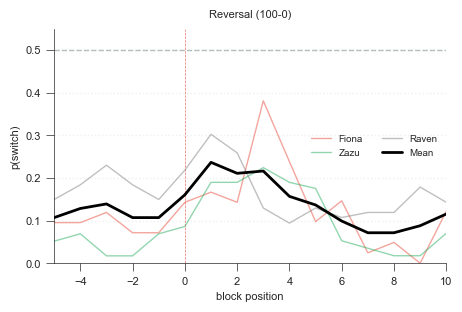


PER-ANIMAL STATISTICS
Fiona       : Pre=0.088, Early=0.214, Late=0.083
Raven       : Pre=0.169, Early=0.201, Late=0.190
Zazu        : Pre=0.047, Early=0.176, Late=0.051


In [114]:

print("Plotting learning curve with individual animals...")

# Calculate overall learning curve (same as before)
learning_curve = reversal_df.groupby('trial_relative').agg({
    'switch': ['mean', 'sem', 'count']
}).reset_index()
learning_curve.columns = ['trial_relative', 'mean_switch', 'sem', 'n_trials']
learning_curve['ci_95'] = 1.96 * learning_curve['sem']

# Calculate learning curve for each animal
animal_curves = {}
for animal in reversal_df['animal'].unique():
    animal_data = reversal_df[reversal_df['animal'] == animal]
    animal_curve = animal_data.groupby('trial_relative')['switch'].mean().reset_index()
    animal_curve.columns = ['trial_relative', 'mean_switch']
    animal_curves[animal] = animal_curve

# Create the figure
fig, ax = plt.subplots(figsize=(5, 3.5))
fig.patch.set_facecolor('white')

# Define colors for animals
animal_colors = {
    'Fiona': '#e74c3c',
    'Knuckles': '#3498db', 
    'Sonic': '#9b59b6',
    'Sunflower': '#f39c12',
    'Zazu': '#27ae60'
}

# Plot individual animal lines FIRST (behind)
for animal, curve_data in animal_curves.items():
    color = animal_colors.get(animal, 'gray')
    ax.plot(curve_data['trial_relative'], curve_data['mean_switch'], 
            color=color, linewidth=1, alpha=0.5, label=animal, zorder=2)

# Plot overall mean on TOP
x = learning_curve['trial_relative']
y = learning_curve['mean_switch']
error = learning_curve['ci_95']

# Shaded error region
# ax.fill_between(x, y - error, y + error, color='black', alpha=0.15, zorder=3)

# Mean line
ax.plot(x, y, color='black', linewidth=2, label='Mean', zorder=4)

# Reference lines
ax.axhline(0.5, color='#95a5a6', linestyle='--', linewidth=1, alpha=0.7, zorder=1)
ax.axhline(optimal_rate, color='#2c3e50', linestyle='--', linewidth=1, alpha=0.7, zorder=1)

# Reversal point
ax.axvline(0, color='#e74c3c', linestyle='--', linewidth=0.5, alpha=0.8, zorder=1)

# Styling
ax.set_xlabel('block position', fontsize=8)
ax.set_ylabel('p(switch)', fontsize=8)
ax.set_title(f'{TASK_TYPE} ({PROB_CONDITION})', 
             fontsize=8, pad=8)
ax.set_ylim([0, 0.55])
ax.set_xlim(-5, 10)
ax.legend(fontsize=7, frameon=False, loc='best', ncol=2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize=8, width=0.5)
ax.grid(axis='y', alpha=0.3, linestyle=':', zorder=0)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)

plt.tight_layout()
plt.savefig(os.path.join(save_path, f'{task_type}_{prob_condition}_learning_curve_switching.svg'), dpi=300)
plt.show()

# Print per-animal statistics
print("\n" + "="*70)
print("PER-ANIMAL STATISTICS")
print("="*70)

for animal in sorted(reversal_df['animal'].unique()):
    animal_data = reversal_df[reversal_df['animal'] == animal]
    
    pre = animal_data[animal_data['trial_relative'] < 0]['switch'].mean()
    early = animal_data[(animal_data['trial_relative'] >= 0) & 
                        (animal_data['trial_relative'] < 5)]['switch'].mean()
    late = animal_data[animal_data['trial_relative'] >= 15]['switch'].mean()
    
    print(f"{animal:12s}: Pre={pre:.3f}, Early={early:.3f}, Late={late:.3f}")
    
print("="*70)

Calculating trials to criterion (PROPER FIX)...

Reversals analyzed: 185
Reversals reaching criterion: 181

Minimum trials to criterion: 4
(Should be at least 4 = 4)

Per animal:
Fiona       : 6.8 trials, 1.2 switches, 41/42 reached criterion
Raven       : 5.6 trials, 1.0 switches, 85/85 reached criterion
Zazu        : 6.9 trials, 1.3 switches, 55/58 reached criterion


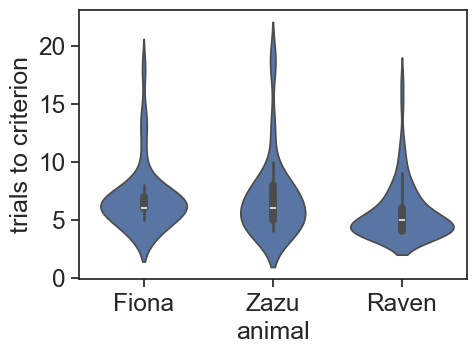

In [115]:
# Cell 9: Trials to Criterion by Animal
# ============================================================================
print("Calculating trials to criterion (PROPER FIX)...")

CRITERION = 0.70
WINDOW_SIZE = 5

learning_metrics = []

# Get the original df and find block transitions directly
for session_id in df['Session_ID'].unique():
    session_df = df[df['Session_ID'] == session_id].sort_values('Trial').copy()
    animal = session_df['Animal_Name'].iloc[0]
    session_type = session_df['Session_Type'].iloc[0]
    
    # Find block changes
    session_df['block_changed'] = session_df['Block'] != session_df['Block'].shift(1)
    block_changes = session_df[session_df['block_changed'] & (session_df.index != session_df.index[0])]
    
    # Process each reversal
    for change_idx in block_changes.index:
        prev_idx = session_df.index[session_df.index.get_loc(change_idx) - 1]
        prev_block = session_df.loc[prev_idx, 'Block']
        curr_block = session_df.loc[change_idx, 'Block']
        
        # Check if this is a reversal
        is_reversal = False
        if session_type == '2-ABT':
            is_reversal = True
        elif prev_block % 2 == 1 and curr_block == prev_block + 1:
            is_reversal = True
        
        if not is_reversal:
            continue
        
        # Get trials starting from this reversal
        reversal_trial_num = session_df.loc[change_idx, 'Trial']
        post_reversal_trials = session_df[session_df['Trial'] >= reversal_trial_num].head(20)  # Look ahead 20 trials max
        
        if len(post_reversal_trials) < WINDOW_SIZE:
            continue
        
        # Calculate trials to criterion
        trials_to_criterion = None
        
        for i in range(len(post_reversal_trials) - WINDOW_SIZE + 1):
            window = post_reversal_trials.iloc[i:i+WINDOW_SIZE]
            # Check if chose correctly (Decision == Target)
            window_perf = (window['Decision'] == window['Target']).mean()
            
            if window_perf >= CRITERION:
                # Report as number of trials after reversal (0-indexed from reversal point)
                trials_to_criterion = i + WINDOW_SIZE - 1  # Index of last trial in window
                break
        
        if trials_to_criterion is None:
            trials_to_criterion = len(post_reversal_trials) - 1
            reached = False
        else:
            reached = True
        
        # Count switches during learning
        learning_window = post_reversal_trials.iloc[:trials_to_criterion+1]
        n_switches = (learning_window['Decision'] != learning_window['Decision'].shift(1)).sum() - 1  # -1 to not count first trial
        
        learning_metrics.append({
            'session_id': session_id,
            'animal': animal,
            'trials_to_criterion': trials_to_criterion,
            'reached_criterion': reached,
            'n_switches': max(0, n_switches)  # Can't be negative
        })

learning_df = pd.DataFrame(learning_metrics)

print(f"\nReversals analyzed: {len(learning_df)}")
print(f"Reversals reaching criterion: {learning_df['reached_criterion'].sum()}")
print(f"\nMinimum trials to criterion: {learning_df[learning_df['reached_criterion']]['trials_to_criterion'].min()}")
print(f"(Should be at least {WINDOW_SIZE-1} = {WINDOW_SIZE-1})")
print()

print("Per animal:")
for animal in sorted(learning_df['animal'].unique()):
    animal_data = learning_df[learning_df['animal'] == animal]
    mean_trials = animal_data['trials_to_criterion'].mean()
    mean_switches = animal_data['n_switches'].mean()
    reached = animal_data['reached_criterion'].sum()
    total = len(animal_data)
    
    print(f"{animal:12s}: {mean_trials:.1f} trials, {mean_switches:.1f} switches, "
          f"{reached}/{total} reached criterion")

# create box plot of trials to criterion by animal
fig, ax = plt.subplots(figsize=(5, 3.5))
sns.violinplot(x='animal', y='trials_to_criterion', data=learning_df, ax=ax)
ax.set_xlabel('animal')
ax.set_ylabel('trials to criterion')
plt.show()


In [39]:
# Check what block transitions exist in the data
print("Checking all block transitions in reversal_df...")

# Look at the transitions captured
transitions = []
for session_id in reversal_df['session_id'].unique():
    session_data = reversal_df[reversal_df['session_id'] == session_id].sort_values('trial_relative')
    
    # Get the blocks around the reversal point
    pre_reversal_block = session_data[session_data['trial_relative'] == -1]['block'].iloc[0] if len(session_data[session_data['trial_relative'] == -1]) > 0 else None
    post_reversal_block = session_data[session_data['trial_relative'] == 0]['block'].iloc[0] if len(session_data[session_data['trial_relative'] == 0]) > 0 else None
    
    if pre_reversal_block is not None and post_reversal_block is not None:
        transitions.append({
            'session': session_id,
            'from_block': pre_reversal_block,
            'to_block': post_reversal_block,
            'transition': f"{int(pre_reversal_block)}→{int(post_reversal_block)}"
        })

transitions_df = pd.DataFrame(transitions)

print("\nTransition types found:")
print(transitions_df['transition'].value_counts())
print()

# Check if there are any even→odd transitions (2→3, 4→5, etc.)
even_to_odd = transitions_df[transitions_df['from_block'] % 2 == 0]
print(f"Even→Odd transitions (e.g., 2→3): {len(even_to_odd)}")
print(f"Odd→Even transitions (e.g., 1→2): {len(transitions_df) - len(even_to_odd)}")

if len(even_to_odd) > 0:
    print("\nExample even→odd transitions:")
    print(even_to_odd.head())

Checking all block transitions in reversal_df...

Transition types found:
1→2     85
5→6      6
3→4      5
9→10     2
7→8      1
Name: transition, dtype: int64

Even→Odd transitions (e.g., 2→3): 0
Odd→Even transitions (e.g., 1→2): 99


In [40]:
# Look at a full session to see the block pattern
example_session = '2023-11-06_Sunflower'
session_data = df[df['Session_ID'] == example_session].sort_values('Trial')

print(f"Session: {example_session}")
print(f"Total trials: {len(session_data)}")
print()

# Show the block pattern across trials
print("Block pattern across session:")
print(session_data[['Trial', 'Block']].head(50))
print("...")
print(session_data[['Trial', 'Block']].tail(20))

# Count how many times blocks change
block_changes = session_data[session_data['Block'] != session_data['Block'].shift(1)]
print(f"\nTotal block changes: {len(block_changes) - 1}")  # -1 because first trial isn't a change
print(f"Block changes at trials: {list(block_changes['Trial'].values[1:])}")

Session: 2023-11-06_Sunflower
Total trials: 253

Block pattern across session:
        Trial  Block
299169      1      1
299170      2      1
299171      3      1
299172      4      1
299173      5      1
299174      6      1
299175      7      1
299176      8      1
299177      9      1
299178     10      1
299179     11      1
299180     12      1
299181     13      1
299182     14      1
299183     15      1
299184     16      1
299185     17      1
299186     18      1
299187     19      1
299188     20      1
299189     21      2
299190     22      2
299191     23      2
299192     24      2
299193     25      2
299194     26      2
299195     27      2
299196     28      2
299197     29      2
299198     30      2
299199     31      2
299200     32      2
299201     33      2
299202     34      2
299203     35      2
299204     36      2
299205     37      2
299206     38      2
299207     39      2
299208     40      2
299209     41      1
299210     42      1
299211     43     


Plotting learning curve...


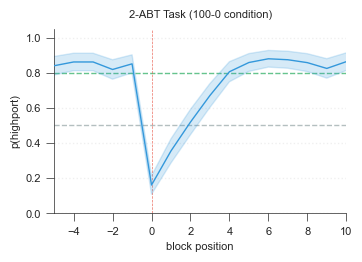


LEARNING CURVE STATISTICS (ALL REVERSALS)
Pre-reversal performance (trials -10 to -1): 0.837 (83.7%)
Early post-reversal (trials 0-4): 0.501 (50.1%)
Late post-reversal (trials 15+): 0.739 (73.9%)

Trials to reach 70% accuracy: -10 trials post-reversal


In [118]:
# Cell 8 COMPLETE: Learning Curve with ALL Reversals Captured
# ============================================================================

# Calculate mean and SEM for each relative trial position
learning_curve = reversal_df.groupby('trial_relative').agg({
    'chose_correct': ['mean', 'sem', 'count']
}).reset_index()

learning_curve.columns = ['trial_relative', 'mean_correct', 'sem', 'n_trials']

# Calculate 95% CI
learning_curve['ci_95'] = 1.96 * learning_curve['sem']

print("\nPlotting learning curve...")

# Create the figure
fig, ax = plt.subplots(figsize=(4, 3))
fig.patch.set_facecolor('white')

# Plot the learning curve
x = learning_curve['trial_relative']
y = learning_curve['mean_correct']
error = learning_curve['ci_95']

# Main line
ax.plot(x, y, color='#3498db', linewidth=1, label='Mean Performance', zorder=3)

# Shaded error region (95% CI)
ax.fill_between(x, y - error, y + error, color='#3498db', alpha=0.2, zorder=2)

# Reference lines
ax.axhline(0.5, color='#95a5a6', linestyle='--', linewidth=1, alpha=0.7, 
           label='Chance (50%)', zorder=1)
ax.axhline(optimal_rate, color='#27ae60', linestyle='--', linewidth=1, alpha=0.7, 
           label=f'Optimal ({optimal_rate:.0%})', zorder=1)

# Reversal point
ax.axvline(0, color='#e74c3c', linestyle='--', linewidth=0.5, alpha=0.8, 
           label='Reversal', zorder=1)

# Styling
ax.set_xlabel('block position', fontsize=8)
ax.set_ylabel('p(highport)', fontsize=8)
ax.set_title(f'2-ABT Task ({PROB_CONDITION} condition)', 
             fontsize=8, pad=8)
ax.set_ylim([0.0, 1.05])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize=8, width=0.5)
ax.grid(axis='y', alpha=0.3, linestyle=':', zorder=0)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)
ax.set_xlim(-5, 10)

plt.tight_layout()
plt.savefig(os.path.join(save_path, f'{task_type}_{prob_condition}_learning_curve_all_reversals.svg'), dpi=300)
plt.show()

# Print summary statistics
print("\n" + "="*70)
print("LEARNING CURVE STATISTICS (ALL REVERSALS)")
print("="*70)
pre_reversal = reversal_df[reversal_df['trial_relative'] < 0]['chose_correct'].mean()
early_post = reversal_df[(reversal_df['trial_relative'] >= 0) & 
                         (reversal_df['trial_relative'] < 5)]['chose_correct'].mean()
late_post = reversal_df[reversal_df['trial_relative'] >= 15]['chose_correct'].mean()

print(f"Pre-reversal performance (trials -10 to -1): {pre_reversal:.3f} ({pre_reversal*100:.1f}%)")
print(f"Early post-reversal (trials 0-4): {early_post:.3f} ({early_post*100:.1f}%)")
print(f"Late post-reversal (trials 15+): {late_post:.3f} ({late_post*100:.1f}%)")

# Calculate trials to criterion
criterion = 0.7
trials_to_criterion = learning_curve[learning_curve['mean_correct'] >= criterion]['trial_relative'].min()
if pd.notna(trials_to_criterion):
    print(f"\nTrials to reach {criterion*100:.0f}% accuracy: {trials_to_criterion:.0f} trials post-reversal")
else:
    print(f"\nDid not reach {criterion*100:.0f}% accuracy within window")
print("="*70)

In [119]:
# Cell 11: Trials to Criterion - PROPERLY FIXED
# ============================================================================

print("Calculating trials to criterion (PROPER FIX)...")

CRITERION = 0.70
WINDOW_SIZE = 5

learning_metrics = []

# Get the original df and find block transitions directly
for session_id in df['Session_ID'].unique():
    session_df = df[df['Session_ID'] == session_id].sort_values('Trial').copy()
    animal = session_df['Animal_Name'].iloc[0]
    session_type = session_df['Session_Type'].iloc[0]
    
    # Find block changes
    session_df['block_changed'] = session_df['Block'] != session_df['Block'].shift(1)
    block_changes = session_df[session_df['block_changed'] & (session_df.index != session_df.index[0])]
    
    # Process each reversal
    for change_idx in block_changes.index:
        prev_idx = session_df.index[session_df.index.get_loc(change_idx) - 1]
        prev_block = session_df.loc[prev_idx, 'Block']
        curr_block = session_df.loc[change_idx, 'Block']
        
        # Check if this is a reversal
        is_reversal = False
        if session_type == '2-ABT':
            is_reversal = True
        elif prev_block % 2 == 1 and curr_block == prev_block + 1:
            is_reversal = True
        
        if not is_reversal:
            continue
        
        # Get trials starting from this reversal
        reversal_trial_num = session_df.loc[change_idx, 'Trial']
        post_reversal_trials = session_df[session_df['Trial'] >= reversal_trial_num].head(20)  # Look ahead 20 trials max
        
        if len(post_reversal_trials) < WINDOW_SIZE:
            continue
        
        # Calculate trials to criterion
        trials_to_criterion = None
        
        for i in range(len(post_reversal_trials) - WINDOW_SIZE + 1):
            window = post_reversal_trials.iloc[i:i+WINDOW_SIZE]
            # Check if chose correctly (Decision == Target)
            window_perf = (window['Decision'] == window['Target']).mean()
            
            if window_perf >= CRITERION:
                # Report as number of trials after reversal (0-indexed from reversal point)
                trials_to_criterion = i + WINDOW_SIZE - 1  # Index of last trial in window
                break
        
        if trials_to_criterion is None:
            trials_to_criterion = len(post_reversal_trials) - 1
            reached = False
        else:
            reached = True
        
        # Count switches during learning
        learning_window = post_reversal_trials.iloc[:trials_to_criterion+1]
        n_switches = (learning_window['Decision'] != learning_window['Decision'].shift(1)).sum() - 1  # -1 to not count first trial
        
        learning_metrics.append({
            'session_id': session_id,
            'animal': animal,
            'trials_to_criterion': trials_to_criterion,
            'reached_criterion': reached,
            'n_switches': max(0, n_switches)  # Can't be negative
        })

learning_df = pd.DataFrame(learning_metrics)

print(f"\nReversals analyzed: {len(learning_df)}")
print(f"Reversals reaching criterion: {learning_df['reached_criterion'].sum()}")
print(f"\nMinimum trials to criterion: {learning_df[learning_df['reached_criterion']]['trials_to_criterion'].min()}")
print(f"(Should be at least {WINDOW_SIZE-1} = {WINDOW_SIZE-1})")
print()

print("Per animal:")
for animal in sorted(learning_df['animal'].unique()):
    animal_data = learning_df[learning_df['animal'] == animal]
    mean_trials = animal_data['trials_to_criterion'].mean()
    mean_switches = animal_data['n_switches'].mean()
    reached = animal_data['reached_criterion'].sum()
    total = len(animal_data)
    
    print(f"{animal:12s}: {mean_trials:.1f} trials, {mean_switches:.1f} switches, "
          f"{reached}/{total} reached criterion")

Calculating trials to criterion (PROPER FIX)...

Reversals analyzed: 185
Reversals reaching criterion: 181

Minimum trials to criterion: 4
(Should be at least 4 = 4)

Per animal:
Fiona       : 6.8 trials, 1.2 switches, 41/42 reached criterion
Raven       : 5.6 trials, 1.0 switches, 85/85 reached criterion
Zazu        : 6.9 trials, 1.3 switches, 55/58 reached criterion


In [45]:
# Check what choice information we have
print("Columns that might indicate physical choice:")
print([col for col in df.columns if any(x in col.lower() for x in ['decision', 'choice', 'target', 'location', 'port', 'side'])])

# Look at an example
example_session = df['Session_ID'].iloc[0]
session_data = df[df['Session_ID'] == example_session].sort_values('Trial').head(30)
print("\nExample trials:")
print(session_data[['Trial', 'Block', 'Decision', 'Target', 'StimuliChosen']].head(30) if 'StimuliChosen' in df.columns else session_data[['Trial', 'Block', 'Decision', 'Target']])

Columns that might indicate physical choice:
['Decision', 'Target', 'PhysicalChoice']

Example trials:
      Trial  Block  Decision  Target StimuliChosen
4702      1      5       0.0       1       TargetB
4703      2      5       1.0       1       TargetA
4704      3      5       1.0       1       TargetA
4705      4      5       0.0       1       TargetB
4706      5      5       1.0       1       TargetA
4707      6      5       1.0       1       TargetA
4708      7      5       0.0       1       TargetB
4709      8      5       0.0       1       TargetB
4710      9      5       0.0       1       TargetB
4711     10      5       1.0       1       TargetA
4712     11      5       0.0       1       TargetB
4713     12      5       0.0       1       TargetB
4714     13      5       0.0       1       TargetB
4715     14      5       0.0       1       TargetB
4716     15      5       0.0       1       TargetB
4717     16      5       0.0       1       TargetB
4718     17      5       1.0  

Calculating switching probability by block position (PHYSICAL LOCATIONS)...
Total trials analyzed: 5640


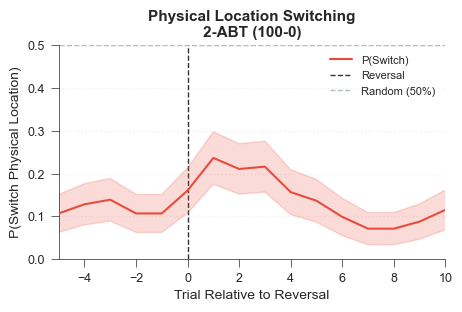


PHYSICAL SWITCHING STATISTICS
Pre-reversal P(switch): 0.113
Early post-reversal (0-4): 0.196
Late post-reversal (15+): 0.120


In [121]:
# Cell 13 FINAL: Switching Probability with Physical Choices
# ============================================================================

print("Calculating switching probability by block position (PHYSICAL LOCATIONS)...")

# Update our filtered df
# df = df_with_choice.copy()

switching_by_position = []

# Process each reversal
for session_id in df['Session_ID'].unique():
    session_df = df[df['Session_ID'] == session_id].sort_values('Trial').copy()
    animal = session_df['Animal_Name'].iloc[0]
    session_type = session_df['Session_Type'].iloc[0]
    
    # Find block changes
    session_df['block_changed'] = session_df['Block'] != session_df['Block'].shift(1)
    block_changes = session_df[session_df['block_changed'] & (session_df.index != session_df.index[0])]
    
    # Process each reversal
    for change_idx in block_changes.index:
        prev_idx = session_df.index[session_df.index.get_loc(change_idx) - 1]
        prev_block = session_df.loc[prev_idx, 'Block']
        curr_block = session_df.loc[change_idx, 'Block']
        
        # Check if reversal
        is_reversal = False
        if session_type == '2-ABT':
            is_reversal = True
        elif prev_block % 2 == 1 and curr_block == prev_block + 1:
            is_reversal = True
        
        if not is_reversal:
            continue
        
        # Get trials around reversal
        reversal_trial_num = session_df.loc[change_idx, 'Trial']
        
        # Look at window around reversal
        window_before = 10
        window_after = 20
        
        for rel_trial in range(-window_before, window_after + 1):
            abs_trial = reversal_trial_num + rel_trial
            
            # Get this trial and previous trial
            current_trial = session_df[session_df['Trial'] == abs_trial]
            prev_trial = session_df[session_df['Trial'] == abs_trial - 1]
            
            if len(current_trial) == 0 or len(prev_trial) == 0:
                continue
            
            # Use PhysicalChoice for actual location
            current_choice = current_trial['PhysicalChoice'].iloc[0]
            prev_choice = prev_trial['PhysicalChoice'].iloc[0]
            
            if pd.isna(current_choice) or pd.isna(prev_choice):
                continue
            
            switched = (current_choice != prev_choice)
            
            switching_by_position.append({
                'session_id': session_id,
                'animal': animal,
                'trial_relative': rel_trial,
                'switched': switched
            })

switching_pos_df = pd.DataFrame(switching_by_position)

print(f"Total trials analyzed: {len(switching_pos_df)}")

# Calculate mean and SEM for each position
switching_curve = switching_pos_df.groupby('trial_relative').agg({
    'switched': ['mean', 'sem', 'count']
}).reset_index()

switching_curve.columns = ['trial_relative', 'mean_switch', 'sem', 'n_trials']
switching_curve['ci_95'] = 1.96 * switching_curve['sem']

# Create figure
fig, ax = plt.subplots(figsize=(5, 3.5))
fig.patch.set_facecolor('white')

# Plot switching curve
x = switching_curve['trial_relative']
y = switching_curve['mean_switch']
error = switching_curve['ci_95']

# Main line
ax.plot(x, y, color='#e74c3c', linewidth=1.5, label='P(Switch)', zorder=3)

# Shaded error region
ax.fill_between(x, y - error, y + error, color='#e74c3c', alpha=0.2, zorder=2)

# Reversal point
ax.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.8, 
           label='Reversal', zorder=1)

# Reference line at 0.5 (random switching)
ax.axhline(0.5, color='#95a5a6', linestyle='--', linewidth=1, alpha=0.7, 
           label='Random (50%)', zorder=1)

# Styling
ax.set_xlabel('Trial Relative to Reversal', fontsize=10)
ax.set_ylabel('P(Switch Physical Location)', fontsize=10)
ax.set_title(f'Physical Location Switching\n2-ABT ({PROB_CONDITION})', 
             fontsize=11, fontweight='bold')
ax.set_ylim([0.0, 0.5])
ax.set_xlim(-5, 10)
ax.legend(fontsize=8, frameon=False, loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)
ax.tick_params(labelsize=9, width=0.5)
ax.grid(axis='y', alpha=0.3, linestyle=':', zorder=0)

plt.tight_layout()
plt.savefig(os.path.join(save_path, f'{task_type}_{prob_condition}_switching_by_position.svg'), dpi=300)
plt.show()

# Print statistics
print("\n" + "="*70)
print("PHYSICAL SWITCHING STATISTICS")
print("="*70)

pre_reversal_switch = switching_pos_df[switching_pos_df['trial_relative'] < 0]['switched'].mean()
early_post_switch = switching_pos_df[(switching_pos_df['trial_relative'] >= 0) & 
                                      (switching_pos_df['trial_relative'] < 5)]['switched'].mean()
late_post_switch = switching_pos_df[switching_pos_df['trial_relative'] >= 15]['switched'].mean()

print(f"Pre-reversal P(switch): {pre_reversal_switch:.3f}")
print(f"Early post-reversal (0-4): {early_post_switch:.3f}")
print(f"Late post-reversal (15+): {late_post_switch:.3f}")
print("="*70)

Creating comprehensive reversal learning figure...


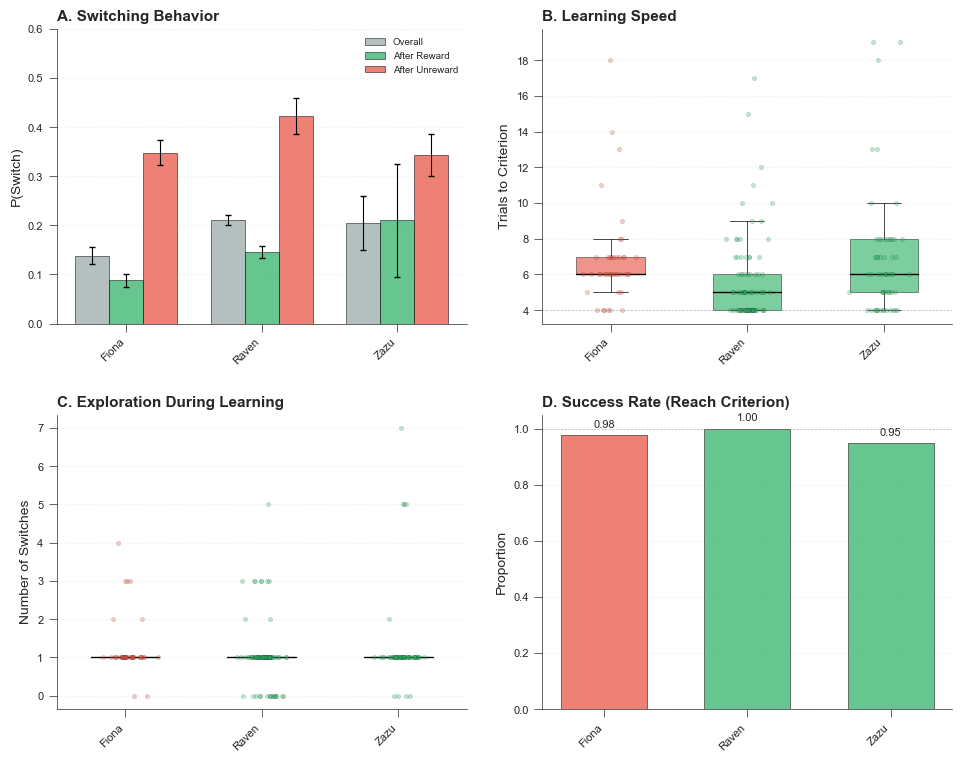


Figure complete!


In [123]:
# Cell 12B: Comprehensive Figure with Error Bars on Panel A
# ============================================================================

print("Creating comprehensive reversal learning figure...")

# Recalculate switching with session-level data for error bars
# ============================================================================
switching_session_data = []

for session_id in df['Session_ID'].unique():
    session_df = df[df['Session_ID'] == session_id].sort_values('Trial').copy()
    animal = session_df['Animal_Name'].iloc[0]
    
    # Create lagged columns
    session_df['prev_decision'] = session_df['Decision'].shift(1)
    session_df['prev_reward'] = session_df['Reward'].shift(1)
    session_df['switched'] = session_df['Decision'] != session_df['prev_decision']
    
    # Remove first trial
    session_df = session_df[session_df['prev_decision'].notna()]
    
    if len(session_df) == 0:
        continue
    
    # Calculate for this session
    overall_switch = session_df['switched'].mean()
    
    after_reward = session_df[session_df['prev_reward'] == 'Rewarded']
    switch_after_reward = after_reward['switched'].mean() if len(after_reward) > 0 else np.nan
    
    after_unreward = session_df[session_df['prev_reward'] == 'Unrewarded']
    switch_after_unreward = after_unreward['switched'].mean() if len(after_unreward) > 0 else np.nan
    
    switching_session_data.append({
        'session_id': session_id,
        'animal': animal,
        'overall_switch': overall_switch,
        'switch_after_reward': switch_after_reward,
        'switch_after_unreward': switch_after_unreward
    })

switching_sessions_df = pd.DataFrame(switching_session_data)

# Calculate means and SEMs per animal
switching_summary = switching_sessions_df.groupby('animal').agg({
    'overall_switch': ['mean', 'sem'],
    'switch_after_reward': ['mean', 'sem'],
    'switch_after_unreward': ['mean', 'sem']
})

# Create figure
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.patch.set_facecolor('white')

# Define colors
animal_colors = {
    'Fiona': '#e74c3c',
    'Knuckles': '#3498db', 
    'Sonic': '#9b59b6',
    'Sunflower': '#f39c12',
    'Zazu': '#27ae60',
    'Raven': '#27ae60'
}

animals = sorted(switching_summary.index)

# Panel A: Switching Probabilities WITH ERROR BARS
# ============================================================================
ax = axes[0, 0]

x_pos = np.arange(len(animals))
width = 0.25

# Prepare data
overall_mean = [switching_summary.loc[a, ('overall_switch', 'mean')] for a in animals]
overall_sem = [switching_summary.loc[a, ('overall_switch', 'sem')] for a in animals]

after_rew_mean = [switching_summary.loc[a, ('switch_after_reward', 'mean')] for a in animals]
after_rew_sem = [switching_summary.loc[a, ('switch_after_reward', 'sem')] for a in animals]

after_unrew_mean = [switching_summary.loc[a, ('switch_after_unreward', 'mean')] for a in animals]
after_unrew_sem = [switching_summary.loc[a, ('switch_after_unreward', 'sem')] for a in animals]

# Plot bars with error bars
ax.bar(x_pos - width, overall_mean, width, label='Overall', 
       color='#95a5a6', alpha=0.7, edgecolor='black', linewidth=0.5)
ax.errorbar(x_pos - width, overall_mean, yerr=overall_sem, 
            fmt='none', ecolor='black', capsize=2, linewidth=0.8, zorder=10)

ax.bar(x_pos, after_rew_mean, width, label='After Reward', 
       color='#27ae60', alpha=0.7, edgecolor='black', linewidth=0.5)
ax.errorbar(x_pos, after_rew_mean, yerr=after_rew_sem, 
            fmt='none', ecolor='black', capsize=2, linewidth=0.8, zorder=10)

ax.bar(x_pos + width, after_unrew_mean, width, label='After Unreward', 
       color='#e74c3c', alpha=0.7, edgecolor='black', linewidth=0.5)
ax.errorbar(x_pos + width, after_unrew_mean, yerr=after_unrew_sem, 
            fmt='none', ecolor='black', capsize=2, linewidth=0.8, zorder=10)

ax.set_ylabel('P(Switch)', fontsize=10)
ax.set_title('A. Switching Behavior', fontsize=11, fontweight='bold', loc='left')
ax.set_xticks(x_pos)
ax.set_xticklabels(animals, fontsize=8, rotation=45, ha='right')
ax.set_ylim([0, 0.6])
ax.legend(fontsize=7, frameon=False, loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)
ax.tick_params(labelsize=8, width=0.5)
ax.grid(axis='y', alpha=0.3, linestyle=':', zorder=0)

# Panel B: Trials to Criterion
# ============================================================================
ax = axes[0, 1]

box_data = [learning_df[learning_df['animal'] == animal]['trials_to_criterion'].values 
            for animal in animals]

bp = ax.boxplot(box_data, positions=range(len(animals)), widths=0.5,
                patch_artist=True, showfliers=False,
                boxprops=dict(linewidth=0.5),
                whiskerprops=dict(linewidth=0.5),
                capprops=dict(linewidth=0.5),
                medianprops=dict(color='black', linewidth=1))

for patch, animal in zip(bp['boxes'], animals):
    patch.set_facecolor(animal_colors[animal])
    patch.set_alpha(0.6)

# Overlay points
for i, animal in enumerate(animals):
    animal_data = learning_df[learning_df['animal'] == animal]['trials_to_criterion'].values
    x_jitter = np.random.normal(i, 0.08, size=len(animal_data))
    ax.scatter(x_jitter, animal_data, color=animal_colors[animal], 
              alpha=0.3, s=10, edgecolors='black', linewidths=0.2, zorder=3)

ax.set_ylabel('Trials to Criterion', fontsize=10)
ax.set_title('B. Learning Speed', fontsize=11, fontweight='bold', loc='left')
ax.set_xticks(range(len(animals)))
ax.set_xticklabels(animals, fontsize=8, rotation=45, ha='right')
ax.axhline(4, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)
ax.tick_params(labelsize=8, width=0.5)
ax.grid(axis='y', alpha=0.3, linestyle=':', zorder=0)

# Panel C: Number of Switches During Learning
# ============================================================================
ax = axes[1, 0]

box_data = [learning_df[learning_df['animal'] == animal]['n_switches'].values 
            for animal in animals]

bp = ax.boxplot(box_data, positions=range(len(animals)), widths=0.5,
                patch_artist=True, showfliers=False,
                boxprops=dict(linewidth=0.5),
                whiskerprops=dict(linewidth=0.5),
                capprops=dict(linewidth=0.5),
                medianprops=dict(color='black', linewidth=1))

for patch, animal in zip(bp['boxes'], animals):
    patch.set_facecolor(animal_colors[animal])
    patch.set_alpha(0.6)

# Overlay points
for i, animal in enumerate(animals):
    animal_data = learning_df[learning_df['animal'] == animal]['n_switches'].values
    x_jitter = np.random.normal(i, 0.08, size=len(animal_data))
    ax.scatter(x_jitter, animal_data, color=animal_colors[animal], 
              alpha=0.3, s=10, edgecolors='black', linewidths=0.2, zorder=3)

ax.set_ylabel('Number of Switches', fontsize=10)
ax.set_title('C. Exploration During Learning', fontsize=11, fontweight='bold', loc='left')
ax.set_xticks(range(len(animals)))
ax.set_xticklabels(animals, fontsize=8, rotation=45, ha='right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)
ax.tick_params(labelsize=8, width=0.5)
ax.grid(axis='y', alpha=0.3, linestyle=':', zorder=0)

# Panel D: Success Rate
# ============================================================================
ax = axes[1, 1]

success_rates = []
for animal in animals:
    animal_data = learning_df[learning_df['animal'] == animal]
    success_rate = animal_data['reached_criterion'].sum() / len(animal_data)
    success_rates.append(success_rate)

bars = ax.bar(range(len(animals)), success_rates, width=0.6,
              color=[animal_colors[a] for a in animals], alpha=0.7,
              edgecolor='black', linewidth=0.5)

ax.set_ylabel('Proportion', fontsize=10)
ax.set_title('D. Success Rate (Reach Criterion)', fontsize=11, fontweight='bold', loc='left')
ax.set_xticks(range(len(animals)))
ax.set_xticklabels(animals, fontsize=8, rotation=45, ha='right')
ax.set_ylim([0, 1.05])
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)
ax.tick_params(labelsize=8, width=0.5)
ax.grid(axis='y', alpha=0.3, linestyle=':', zorder=0)

# Add value labels
for bar, val in zip(bars, success_rates):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{val:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(save_path, f'{task_type}_{prob_condition}_comprehensive_figure.svg'), dpi=300)
plt.show()

print("\nFigure complete!")

Calculating performance by reversal epoch...
Pre-Reversal
(-6 to -1): 0.738 ± 0.004 (n=10506 trials)
Early Post
(0 to 4): 0.522 ± 0.005 (n=8716 trials)
Late Post
(10 to 15): 0.744 ± 0.004 (n=10144 trials)


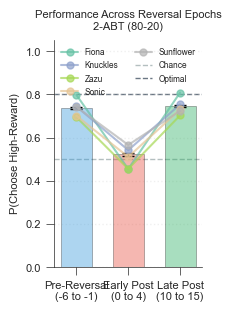


EPOCH COMPARISONS
Pre-Reversal vs Early Post: t=13.271, p=0.0000 (n=99 sessions)
Early Post vs Late Post: t=-15.958, p=0.0000 (n=97 sessions)
Pre-Reversal vs Late Post: t=-0.306, p=0.7604 (n=97 sessions)


In [79]:
# Cell 10: Performance by Epoch with Animal Trajectories
# ============================================================================

print("Calculating performance by reversal epoch...")

# Define epochs
epochs = {
    'Pre-Reversal\n(-6 to -1)': (-6, -1),
    'Early Post\n(0 to 4)': (0, 4),
    'Late Post\n(10 to 15)': (10, 15)
}

# Calculate overall performance for each epoch
epoch_performance = []

for epoch_name, (start, end) in epochs.items():
    epoch_trials = reversal_df[
        (reversal_df['trial_relative'] >= start) & 
        (reversal_df['trial_relative'] <= end)
    ]
    
    mean_perf = epoch_trials['chose_correct'].mean()
    sem_perf = epoch_trials['chose_correct'].sem()
    n_trials = len(epoch_trials)
    
    epoch_performance.append({
        'epoch': epoch_name,
        'mean': mean_perf,
        'sem': sem_perf,
        'n_trials': n_trials
    })
    
    print(f"{epoch_name}: {mean_perf:.3f} ± {sem_perf:.3f} (n={n_trials} trials)")

epoch_df = pd.DataFrame(epoch_performance)

# Calculate animal-level performance for each epoch
animal_epoch_data = []
for animal in reversal_df['animal'].unique():
    animal_data = reversal_df[reversal_df['animal'] == animal]
    animal_row = {'animal': animal}
    
    for epoch_name, (start, end) in epochs.items():
        epoch_trials = animal_data[
            (animal_data['trial_relative'] >= start) & 
            (animal_data['trial_relative'] <= end)
        ]
        if len(epoch_trials) > 0:
            animal_row[epoch_name] = epoch_trials['chose_correct'].mean()
        else:
            animal_row[epoch_name] = np.nan
    
    animal_epoch_data.append(animal_row)

animal_epoch_df = pd.DataFrame(animal_epoch_data)

# Create figure
fig, ax = plt.subplots(figsize=(2.5, 3.5))
fig.patch.set_facecolor('white')

# Define colors
colors = ['#3498db', '#e74c3c', '#27ae60']
animal_colors = plt.cm.Set2(np.linspace(0, 1, len(animal_epoch_df)))

# Plot bars with error bars
x_pos = np.arange(len(epoch_df))
bars = ax.bar(x_pos, epoch_df['mean'], 
              color=colors, alpha=0.4, width=0.6,
              edgecolor='black', linewidth=0.5, zorder=1, )

# Add error bars
ax.errorbar(x_pos, epoch_df['mean'], 
            yerr=epoch_df['sem'],
            fmt='none', ecolor='black', capsize=4, linewidth=1, zorder=2)

# Plot individual animal trajectories
epoch_names = list(epochs.keys())
for i, (_, animal_row) in enumerate(animal_epoch_df.iterrows()):
    y_vals = [animal_row[epoch] for epoch in epoch_names]
    
    # Only plot if animal has data for all epochs
    if not any(pd.isna(y_vals)):
        ax.plot(x_pos, y_vals, 'o-', color=animal_colors[i], 
                linewidth=1.5, markersize=5, alpha=0.7, 
                label=animal_row['animal'], zorder=3)

# Reference lines
ax.axhline(0.5, color='#95a5a6', linestyle='--', linewidth=1, alpha=0.7, 
           label='Chance', zorder=0)
ax.axhline(optimal_rate, color='#2c3e50', linestyle='--', linewidth=1, alpha=0.7, 
           label='Optimal', zorder=0)

# Styling
ax.set_xticks(x_pos)
ax.set_xticklabels(epoch_df['epoch'], fontsize=8)
ax.set_ylabel('P(Choose High-Reward)', fontsize=8)
ax.set_title(f'Performance Across Reversal Epochs\n2-ABT ({PROB_CONDITION})', 
             fontsize=8, pad=8)
ax.set_ylim([0, 1.05])
ax.legend(fontsize=6, frameon=False, loc='upper center', ncol=2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)
ax.tick_params(labelsize=8, width=0.5)
ax.grid(axis='y', alpha=0.3, linestyle=':', zorder=0)

plt.tight_layout()
plt.savefig(os.path.join(save_path, f'{task_type}_{prob_condition}_performance_by_reversal_epoch.svg'), dpi=300)
plt.show()

# Statistical comparisons
print("\n" + "="*70)
print("EPOCH COMPARISONS")
print("="*70)

from scipy import stats

# Get session-level means for each epoch
pre_session = reversal_df[reversal_df['trial_relative'].between(-6, -1)].groupby('session_id')['chose_correct'].mean()
early_session = reversal_df[reversal_df['trial_relative'].between(0, 4)].groupby('session_id')['chose_correct'].mean()
late_session = reversal_df[reversal_df['trial_relative'].between(10, 15)].groupby('session_id')['chose_correct'].mean()

# Pre vs Early
common_sessions_pre_early = pre_session.index.intersection(early_session.index)
if len(common_sessions_pre_early) > 1:
    t_pre_early, p_pre_early = stats.ttest_rel(
        pre_session[common_sessions_pre_early],
        early_session[common_sessions_pre_early]
    )
    print(f"Pre-Reversal vs Early Post: t={t_pre_early:.3f}, p={p_pre_early:.4f} (n={len(common_sessions_pre_early)} sessions)")

# Early vs Late
common_sessions_early_late = early_session.index.intersection(late_session.index)
if len(common_sessions_early_late) > 1:
    t_early_late, p_early_late = stats.ttest_rel(
        early_session[common_sessions_early_late],
        late_session[common_sessions_early_late]
    )
    print(f"Early Post vs Late Post: t={t_early_late:.3f}, p={p_early_late:.4f} (n={len(common_sessions_early_late)} sessions)")

# Pre vs Late
common_sessions_pre_late = pre_session.index.intersection(late_session.index)
if len(common_sessions_pre_late) > 1:
    t_pre_late, p_pre_late = stats.ttest_rel(
        pre_session[common_sessions_pre_late],
        late_session[common_sessions_pre_late]
    )
    print(f"Pre-Reversal vs Late Post: t={t_pre_late:.3f}, p={p_pre_late:.4f} (n={len(common_sessions_pre_late)} sessions)")

print("="*70)